# Лабораторная работа: Экстраполяция данных

- Студент: Платов Дмитрий Константинович
- Группа: 6
- Дата: 05.05.26

### Цель работы
Изучение методов экстраполяции данных, получение начальных
навыков работы с библиотекой pandas и методы аппроксимации в библиотеке numpy.

<br><br>
### Ход работы

### 1. Импорт необходимых библиотек и чтение данных из файла

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.polynomial import Polynomial

df = pd.read_csv('Task_data_EURUSD.csv', sep=';')
df

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>
0,EURUSD,D,210201,0,1.2122700,1.21365,1.20530,1.20677
1,EURUSD,D,210202,0,1.2067700,1.20878,1.20100,1.20360
2,EURUSD,D,210203,0,NaN,1.20502,1.20020,1.20410
3,EURUSD,D,210204,0,1.2041300,1.20430,1.19560,1.19656
4,EURUSD,D,210205,0,1.1966300,1.20500,1.19510,1.20476
5,EURUSD,D,210207,0,1.2046000,1.20551,1.20327,1.20484
6,EURUSD,D,210208,0,1.2048400,1.20660,1.20180,1.20510
7,EURUSD,D,210209,0,1.2dvv052200,1.21220,1.20480,1.21156
8,EURUSD,D,210210,0,1.2115800,1.21441,1.21070,1.21191
9,EURUSD,D,210211,0,1.2117900,1.21495,1.21110,1.21297


### 2. Подготовка данных

In [18]:
df.info()
df['<OPEN>'] = pd.to_numeric(df['<OPEN>'], errors='coerce')
df['<OPEN>'] = df['<CLOSE>'].dropna().astype('float64')
df

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   <TICKER>  25 non-null     str    
 1   <PER>     25 non-null     str    
 2   <DATE>    25 non-null     int64  
 3   <TIME>    25 non-null     int64  
 4   <OPEN>    24 non-null     str    
 5   <HIGH>    25 non-null     float64
 6   <LOW>     25 non-null     float64
 7   <CLOSE>   25 non-null     float64
dtypes: float64(3), int64(2), str(3)
memory usage: 1.7 KB


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>
0,EURUSD,D,210201,0,1.20677,1.21365,1.20530,1.20677
1,EURUSD,D,210202,0,1.20360,1.20878,1.20100,1.20360
2,EURUSD,D,210203,0,1.20410,1.20502,1.20020,1.20410
3,EURUSD,D,210204,0,1.19656,1.20430,1.19560,1.19656
4,EURUSD,D,210205,0,1.20476,1.20500,1.19510,1.20476
5,EURUSD,D,210207,0,1.20484,1.20551,1.20327,1.20484
6,EURUSD,D,210208,0,1.20510,1.20660,1.20180,1.20510
7,EURUSD,D,210209,0,1.21156,1.21220,1.20480,1.21156
8,EURUSD,D,210210,0,1.21191,1.21441,1.21070,1.21191
9,EURUSD,D,210211,0,1.21297,1.21495,1.21110,1.21297


### 3.Построение аппроксимации

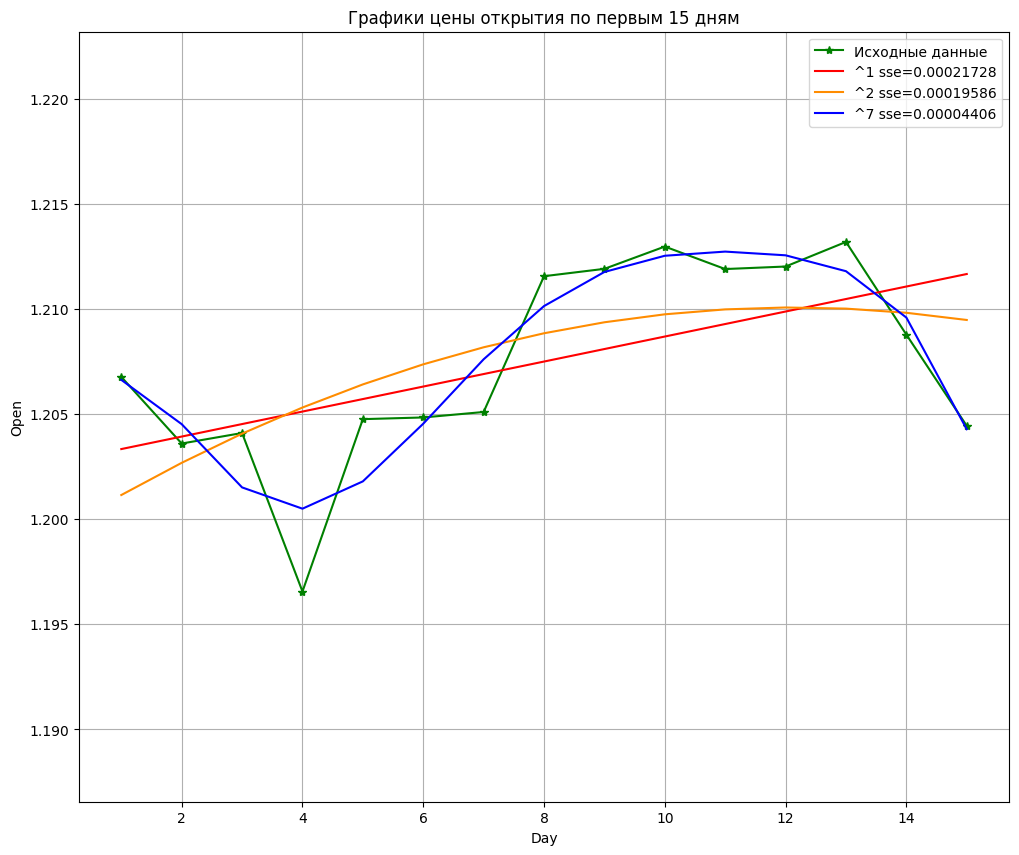

In [77]:
EPS = 0.01

# построение полиномов
arange = np.arange(1, 16)
approximation_polynomial_k1 = Polynomial.fit(arange, df['<OPEN>'].to_numpy()[:15], deg=1)
approximation_polynomial_k2 = Polynomial.fit(arange, df['<OPEN>'].to_numpy()[:15], deg=2)
approximation_polynomial_k7 = Polynomial.fit(arange, df['<OPEN>'].to_numpy()[:15], deg=7)

# реальные значения
x = np.arange(1, df['<OPEN>'].size + 1)
y_from_file = df['<OPEN>'].to_numpy()

# для 15 первых значений
x_cropped = x[:15]
y_cropped = y_from_file[:15]
sse_cropped_1 = np.sum((y_cropped - approximation_polynomial_k1(x_cropped)) ** 2)
sse_cropped_2 = np.sum((y_cropped - approximation_polynomial_k2(x_cropped)) ** 2)
sse_cropped_7 = np.sum((y_cropped - approximation_polynomial_k7(x_cropped)) ** 2)

plt.figure(figsize=(12, 10))
plt.xlabel('Day')
plt.ylabel('Open')
plt.ylim(np.min(y_cropped) - EPS, np.max(y_cropped) + EPS)
plt.plot(x_cropped, y_cropped, marker='*', color='green', label='Исходные данные')
plt.plot(x_cropped, approximation_polynomial_k1(x_cropped), color='red', label=f'^1 sse={np.round(sse_cropped_1, 8)}')
plt.plot(x_cropped, approximation_polynomial_k2(x_cropped), color='darkorange',
         label=f'^2 sse={np.round(sse_cropped_2, 8)}')
plt.plot(x_cropped, approximation_polynomial_k7(x_cropped), color='blue', label=f'^7 sse={sse_cropped_7:.8f}')
plt.title('Графики цены открытия по первым 15 дням')
plt.legend()
plt.grid(True)
plt.show()

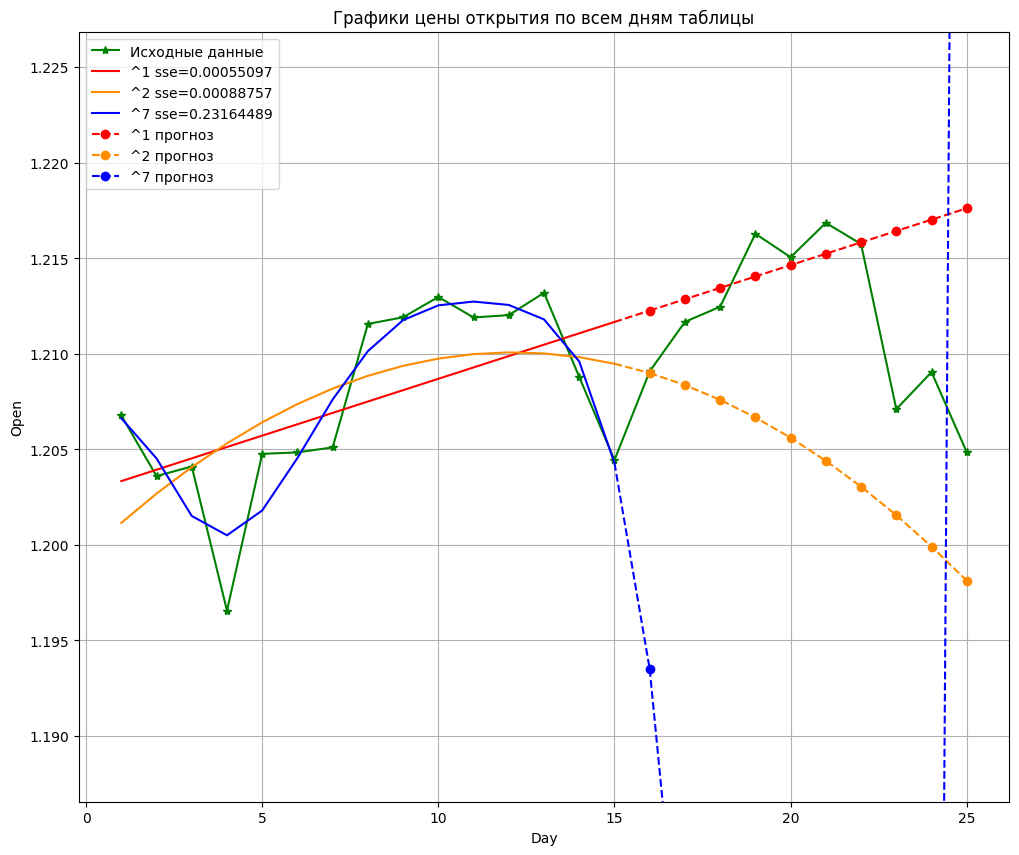

In [84]:
sse_1 = np.sum((y_from_file - approximation_polynomial_k1(x)) ** 2)
sse_2 = np.sum((y_from_file - approximation_polynomial_k2(x)) ** 2)
sse_3 = np.sum((y_from_file - approximation_polynomial_k7(x)) ** 2)

plt.figure(figsize=(12, 10))
plt.xlabel('Day')
plt.ylabel('Open')
plt.ylim(np.min(y_from_file) - EPS, np.max(y_from_file) + EPS)

plt.plot(x, y_from_file, marker='*', color='green', label='Исходные данные')
plt.plot(x_cropped, approximation_polynomial_k1(x_cropped), color='red', label=f'^1 sse={sse_1:.8f}')
plt.plot(x_cropped, approximation_polynomial_k2(x_cropped), color='darkorange', label=f'^2 sse={sse_2:.8f}')
plt.plot(x_cropped, approximation_polynomial_k7(x_cropped), color='blue', label=f'^7 sse={sse_3:.8f}')

plt.plot(x[14:16], approximation_polynomial_k1(x[14:16]), ls='--', color='red')
plt.plot(x[14:16], approximation_polynomial_k2(x[14:16]), ls='--', color='darkorange')
plt.plot(x[14:16], approximation_polynomial_k7(x[14:16]), ls='--', color='blue')

plt.plot(x[15:], approximation_polynomial_k1(x[15:]), ls='--', marker='o', color='red', label='^1 прогноз')
plt.plot(x[15:], approximation_polynomial_k2(x[15:]), ls='--', marker='o', color='darkorange', label='^2 прогноз')
plt.plot(x[15:], approximation_polynomial_k7(x[15:]), ls='--', marker='o', color='blue', label='^7 прогноз')
plt.title('Графики цены открытия по всем дням таблицы')
plt.legend()
plt.grid(True)
plt.show()

### 4. Выводы

- Точность аппроксимации (внутри интервала): С увеличением степени полинома точность описания исходных данных растет, а сумма квадратов ошибок (SSE) снижается. Полином 7-й степени обеспечивает минимальное отклонение от точек, так как его гибкости достаточно для прохождения практически через каждый узел обучающей выборки.
- Точность прогнозирования (вне интервала): Высокая степень полинома приводит к переобучению: модель начинает описывать случайный шум, а не общую закономерность. Это вызывает резкие и нереалистичные колебания за пределами известных данных. В то же время модели низких степеней (1 и 2) лучше сохраняют общий тренд и дают более стабильный, хоть и упрощенный прогноз.